In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')


In [2]:
TRAIN_DIR = '../dataset/Train'
TEST_DIR = '../dataset/Test'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CLASSES = ['glioma', 'meningioma', 'notumor', 'pituitary']

print(f"Image Size : {IMG_SIZE}")
print(f"Batch Size : {BATCH_SIZE}")
print(f"Classes    : {CLASSES}")

Image Size : (224, 224)
Batch Size : 32
Classes    : ['glioma', 'meningioma', 'notumor', 'pituitary']


In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    brightness_range=[0.9, 1.1],
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

print("\nClass Indices:", train_generator.class_indices)

Found 7722 images belonging to 4 classes.
Found 1928 images belonging to 4 classes.

Class Indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [4]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Test generator ready!")
print(f"Test samples: {test_generator.samples}")

Found 2414 images belonging to 4 classes.
Test generator ready!
Test samples: 2414


In [5]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2, 3]),
    y=train_generator.classes
)

class_weight_dict = dict(enumerate(class_weights))
print("Class Weights:")
for k, v in class_weight_dict.items():
    print(f"  Class {k} ({CLASSES[k]}): {v:.4f}")

Class Weights:
  Class 0 (glioma): 0.7994
  Class 1 (meningioma): 1.1050
  Class 2 (notumor): 1.2407
  Class 3 (pituitary): 0.9633


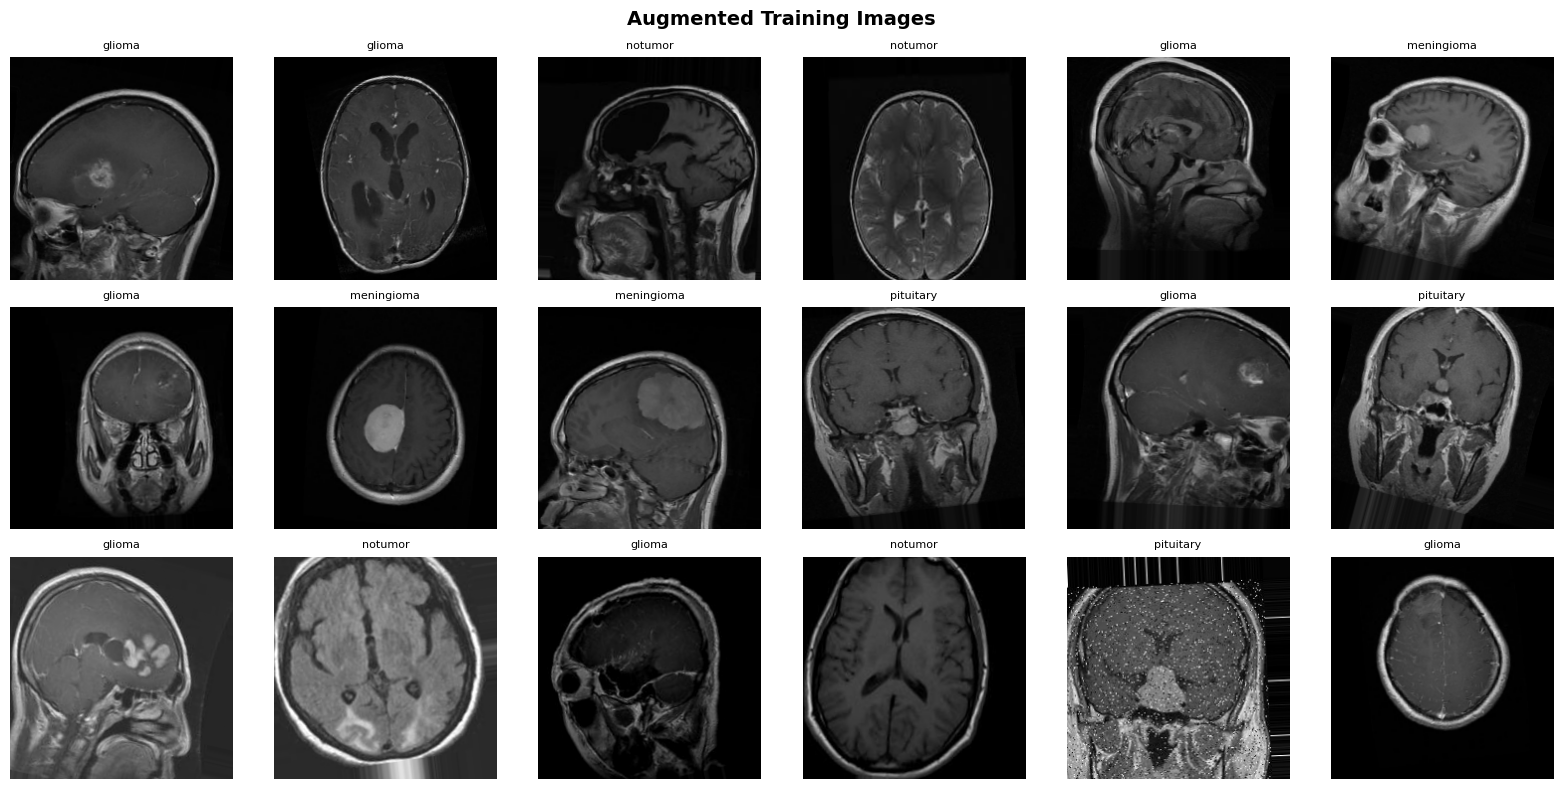

In [7]:
sample_batch, sample_labels = next(train_generator)

fig, axes = plt.subplots(3, 6, figsize=(16, 8))
fig.suptitle('Augmented Training Images', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_batch[i])
    ax.set_title(CLASSES[np.argmax(sample_labels[i])], fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('../notebooks/augmented_samples.png', dpi=150)
plt.show()


In [8]:
import json

config = {
    "img_size": list(IMG_SIZE),
    "batch_size": BATCH_SIZE,
    "classes": CLASSES,
    "class_weight": {str(k): v for k, v in class_weight_dict.items()},
    "train_samples": train_generator.samples,
    "val_samples": val_generator.samples,
    "test_samples": test_generator.samples
}

with open('../notebooks/config.json', 'w') as f:
    json.dump(config, f, indent=4)

print("Config saved!")
print(json.dumps(config, indent=4))

Config saved!
{
    "img_size": [
        224,
        224
    ],
    "batch_size": 32,
    "classes": [
        "glioma",
        "meningioma",
        "notumor",
        "pituitary"
    ],
    "class_weight": {
        "0": 0.7993788819875777,
        "1": 1.1050372066399543,
        "2": 1.2406812339331619,
        "3": 0.9633233532934131
    },
    "train_samples": 7722,
    "val_samples": 1928,
    "test_samples": 2414
}
